In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Ready to go!")

Ready to go!


In [81]:
import os
os.chdir('C:\\Users\\44748\\OneDrive - University of Cambridge\\Documents\\Year 3\\Engineering\\GM2\\GM2_Aqua_Solutions')
print(os.listdir('.'))

['.claude', '.git', '.gitattributes', '.gitignore', '.venv', '.vscode', 'App', 'CLAUDE.md', 'Data', 'ISSUES.md', 'Meetings', 'ML', 'PLAN.md', 'Presentations', 'README.md', 'Research', 'WNTR']


In [82]:
# Load water potability data
df = pd.read_csv('Data/full_dataset.csv')

print(df.shape)
print(df.head())
print(df.info())

(25625, 15)
                wma period_start  period_end  site_id  \
0  Pongola_Mtamvuna   1990-01-01  1990-02-28   102626   
1  Pongola_Mtamvuna   1990-01-01  1990-02-28   102626   
2  Pongola_Mtamvuna   1990-01-01  1990-02-28   102626   
3  Pongola_Mtamvuna   1990-01-01  1990-02-28   102626   
4  Pongola_Mtamvuna   1990-01-01  1990-02-28   102626   

                      site_name        date  ecoli_per_100ml  \
0  Msunduze River at Henley Dam  1990-01-02            580.0   
1  Msunduze River at Henley Dam  1990-01-08           2100.0   
2  Msunduze River at Henley Dam  1990-01-15          12400.0   
3  Msunduze River at Henley Dam  1990-01-22           3500.0   
4  Msunduze River at Henley Dam  1990-01-29           2800.0   

   faecal_coliforms_per_100ml  turbidity_ntu   ph  temperature_c  \
0                         NaN           26.0  8.1           22.7   
1                         NaN           27.0  7.6           18.2   
2                         NaN          200.0  7.6       

In [83]:
# Basic exploration
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\n\nData types:")
print(df.dtypes)

print("\n\nMissing values:")
print(df.isnull().sum())

print("\n\nBasic statistics:")
print(df.describe())

Dataset shape: (25625, 15)

First few rows:
                wma period_start  period_end  site_id  \
0  Pongola_Mtamvuna   1990-01-01  1990-02-28   102626   
1  Pongola_Mtamvuna   1990-01-01  1990-02-28   102626   
2  Pongola_Mtamvuna   1990-01-01  1990-02-28   102626   
3  Pongola_Mtamvuna   1990-01-01  1990-02-28   102626   
4  Pongola_Mtamvuna   1990-01-01  1990-02-28   102626   

                      site_name        date  ecoli_per_100ml  \
0  Msunduze River at Henley Dam  1990-01-02            580.0   
1  Msunduze River at Henley Dam  1990-01-08           2100.0   
2  Msunduze River at Henley Dam  1990-01-15          12400.0   
3  Msunduze River at Henley Dam  1990-01-22           3500.0   
4  Msunduze River at Henley Dam  1990-01-29           2800.0   

   faecal_coliforms_per_100ml  turbidity_ntu   ph  temperature_c  \
0                         NaN           26.0  8.1           22.7   
1                         NaN           27.0  7.6           18.2   
2                       

# Step 1: Check class distribution

Before building a model, we need to understand how balanced the target classes are. Heavy imbalance means raw accuracy is misleading â€” a model that just says "HIGH" every time would score ~95% accuracy but be useless for detecting safe water.

In [84]:
target = 'risk_drinking_no_treatment'

counts = df[target].value_counts()
proportions = df[target].value_counts(normalize=True) * 100

print("Class counts:")
print(counts)
print("\nClass proportions (%):")
print(proportions.round(1))

Class counts:
risk_drinking_no_treatment
HIGH    24283
Med       943
low       399
Name: count, dtype: int64

Class proportions (%):
risk_drinking_no_treatment
HIGH    94.8
Med      3.7
low      1.6
Name: proportion, dtype: float64


# Step 2: Feature prep

We use only the three cheap field-measurable sensors: pH, turbidity, temperature.

- `ecoli_per_100ml` is excluded â€” the label was derived from it (target leakage)
- `temperature_c` has 45% missing values â€” we impute with the median and add a missingness indicator column so the model knows when temperature was unavailable

In [85]:
FEATURES = ['ph', 'turbidity_ntu', 'temperature_c', 'temperature_missing']
TARGET = 'risk_drinking_no_treatment'

df_model = df.copy()

# Add missingness indicator before imputing
df_model['temperature_missing'] = df_model['temperature_c'].isna().astype(int)

# Impute temperature with median
temp_median = df_model['temperature_c'].median()
df_model['temperature_c'] = df_model['temperature_c'].fillna(temp_median)

print(f"Temperature median used for imputation: {temp_median:.1f} Â°C")
print(f"Rows with imputed temperature: {df_model['temperature_missing'].sum()}")
print(f"\nFeatures shape: {df_model[FEATURES].shape}")
print(df_model[FEATURES].isnull().sum())

Temperature median used for imputation: 20.0 Â°C
Rows with imputed temperature: 11556

Features shape: (25625, 4)
ph                     0
turbidity_ntu          0
temperature_c          0
temperature_missing    0
dtype: int64


# Step 3: Grouped temporal train/test split

A random split would leak data â€” the same borehole site appears hundreds of times, so a random split lets the model memorise site characteristics rather than learning water chemistry patterns.

Instead we split by `site_id`: **80% of sites go to train, 20% to test**. No site appears in both sets. Within each set the rows are also sorted by date so that if we later do time-series cross-validation, the order is correct.

In [86]:
from sklearn.model_selection import GroupShuffleSplit

df_model['date'] = pd.to_datetime(df_model['date'])
df_model = df_model.sort_values('date').reset_index(drop=True)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df_model, groups=df_model['site_id']))

train_df = df_model.iloc[train_idx]
test_df  = df_model.iloc[test_idx]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f"Train: {len(train_df)} rows, {train_df['site_id'].nunique()} sites")
print(f"Test:  {len(test_df)} rows, {test_df['site_id'].nunique()} sites")
print(f"\nSite overlap (should be 0): {len(set(train_df['site_id']) & set(test_df['site_id']))}")
print(f"\nTrain class distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(1))

Train: 19820 rows, 150 sites
Test:  5805 rows, 38 sites

Site overlap (should be 0): 0

Train class distribution:
risk_drinking_no_treatment
HIGH    94.5
Med      3.7
low      1.7
Name: proportion, dtype: float64


# Step 4: Train XGBoost classifier

Key settings:
- `class_weight='balanced'` â€” automatically upweights LOW and Med samples so the model doesn't just predict HIGH every time
- We encode the string labels (HIGH/Med/low) as integers since XGBoost requires numeric targets
- `eval_metric='mlogloss'` â€” multiclass log loss, appropriate for a 3-class problem

In [87]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# Compute per-class weights to handle imbalance
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train_enc)

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train_enc, sample_weight=sample_weights)
print("Training complete.")

Label encoding: {'HIGH': np.int64(0), 'Med': np.int64(1), 'low': np.int64(2)}


c:\Users\44748\OneDrive - University of Cambridge\Documents\Year 3\Engineering\GM2\GM2_Aqua_Solutions\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:22:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training complete.


# Step 5: Evaluate the model

Raw accuracy is misleading with 95% class imbalance. We care about:
- **Per-class recall**: of all actual HIGH/Med/low rows, what fraction did we correctly identify?
- **Macro-F1**: average F1 across all three classes equally weighted â€” penalises poor minority-class performance
- **Confusion matrix**: shows exactly where the model is making mistakes

Classification report:
              precision    recall  f1-score   support

        HIGH      0.985     0.851     0.913      5551
         Med      0.170     0.527     0.257       201
         low      0.044     0.321     0.078        53

    accuracy                          0.835      5805
   macro avg      0.400     0.566     0.416      5805
weighted avg      0.949     0.835     0.883      5805



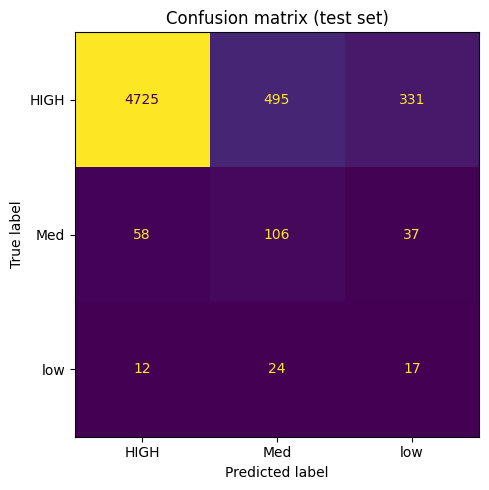

In [88]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_enc = model.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)

print("Classification report:")
print(classification_report(y_test, y_pred, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

# Step 6: Logistic Regression baseline

Logistic regression is a simpler linear model. Unlike XGBoost, it assumes a linear decision boundary and is sensitive to feature scale â€” so we standardise features first (subtract mean, divide by std) using a sklearn Pipeline.

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
    ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr, digits=3))

print("\nXGBoost (for comparison):")
print(classification_report(y_test, y_pred, digits=3))

Logistic Regression:
              precision    recall  f1-score   support

        HIGH      0.986     0.779     0.871      5551
         Med      0.062     0.353     0.106       201
         low      0.066     0.340     0.111        53

    accuracy                          0.761      5805
   macro avg      0.371     0.491     0.362      5805
weighted avg      0.945     0.761     0.837      5805


XGBoost (for comparison):
              precision    recall  f1-score   support

        HIGH      0.985     0.851     0.913      5551
         Med      0.170     0.527     0.257       201
         low      0.044     0.321     0.078        53

    accuracy                          0.835      5805
   macro avg      0.400     0.566     0.416      5805
weighted avg      0.949     0.835     0.883      5805



# Feature Importance

XGBoost tracks three importance measures:
- **Gain**: how much each feature reduces prediction error when it's used for a split â€” the most meaningful metric
- **Weight**: how many times a feature is used across all trees
- **Cover**: how many samples are affected by splits on that feature

We plot all three so we can see if they agree. If turbidity has high gain but low weight, it means it's only used occasionally but is very decisive when it is.

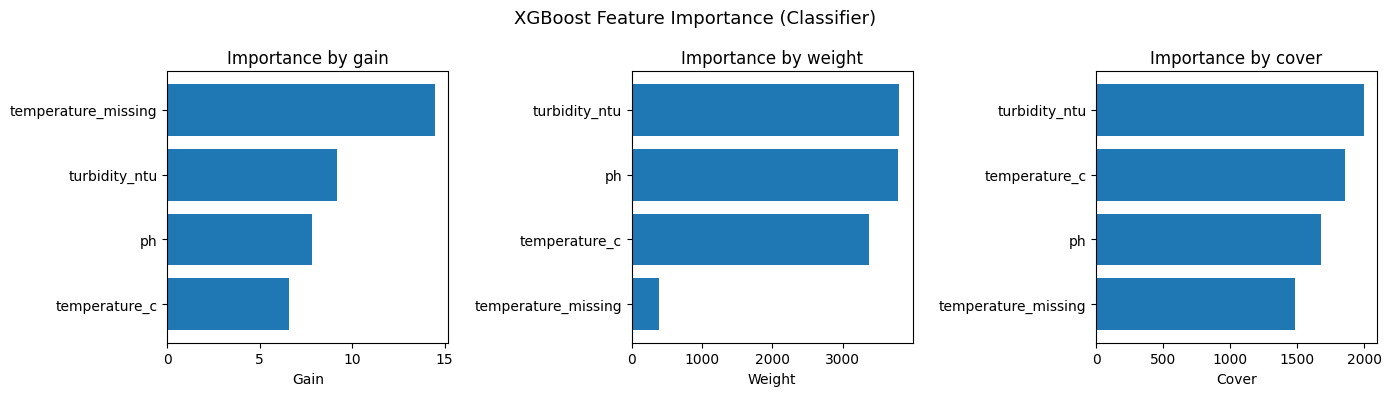

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, importance_type in zip(axes, ['gain', 'weight', 'cover']):
    scores = model.get_booster().get_score(importance_type=importance_type)
    # Fill in zero for any feature not used
    scores = {f: scores.get(f, 0) for f in FEATURES}
    sorted_scores = dict(sorted(scores.items(), key=lambda x: x[1]))
    ax.barh(list(sorted_scores.keys()), list(sorted_scores.values()))
    ax.set_title(f'Importance by {importance_type}')
    ax.set_xlabel(importance_type.capitalize())

plt.suptitle("XGBoost Feature Importance (Classifier)", fontsize=13)
plt.tight_layout()
plt.show()

# Step 7: XGBoost Regression on E. coli count

Instead of classifying directly, we predict the E. coli count as a continuous value, then threshold predictions into risk bands. This is a more natural framing since the risk labels were derived from the count.

Key decisions:
- Drop rows missing `ecoli_per_100ml` (~4500 rows gone, ~21k remain)
- Log-transform the target: E. coli counts span 0â€“50M and are extremely right-skewed
- Re-run the grouped site split on this smaller dataset
- After predicting, convert back and threshold into HIGH/Med/low for comparison

Regression dataset: 21094 rows
Train: 15726 rows | Test: 5368 rows
Site overlap: 0

RMSE (log scale): 2.321
RÂ²:               -0.166


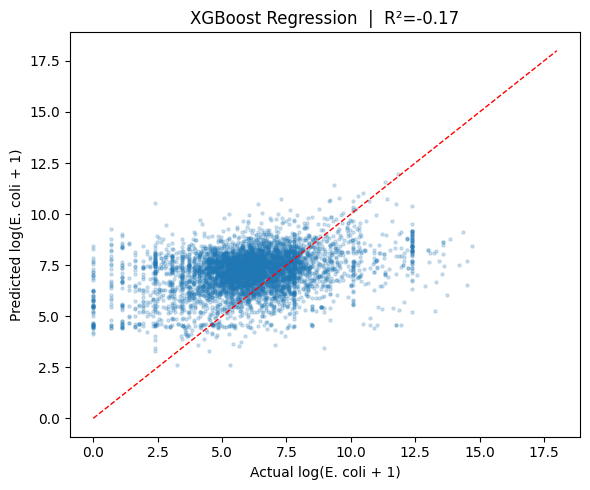

In [92]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Build regression dataset â€” only rows with a measured E. coli count
df_reg = df_model.dropna(subset=['ecoli_per_100ml']).copy()
print(f"Regression dataset: {len(df_reg)} rows")

# Log-transform target (add 1 to handle zeros)
df_reg['log_ecoli'] = np.log1p(df_reg['ecoli_per_100ml'])

# Re-run grouped split on this subset
splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx2, test_idx2 = next(splitter2.split(df_reg, groups=df_reg['site_id']))

train_reg = df_reg.iloc[train_idx2]
test_reg  = df_reg.iloc[test_idx2]

X_train_r = train_reg[FEATURES]
y_train_r = train_reg['log_ecoli']
X_test_r  = test_reg[FEATURES]
y_test_r  = test_reg['log_ecoli']

print(f"Train: {len(train_reg)} rows | Test: {len(test_reg)} rows")
print(f"Site overlap: {len(set(train_reg['site_id']) & set(test_reg['site_id']))}")

# Fit XGBoost regressor
reg_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
reg_model.fit(X_train_r, y_train_r)

y_pred_log = reg_model.predict(X_test_r)

rmse_log = np.sqrt(mean_squared_error(y_test_r, y_pred_log))
r2 = r2_score(y_test_r, y_pred_log)
print(f"\nRMSE (log scale): {rmse_log:.3f}")
print(f"RÂ²:               {r2:.3f}")

# Convert back to original scale for inspection
y_pred_ecoli = np.expm1(y_pred_log)
y_true_ecoli = np.expm1(y_test_r)

# Quick plot: predicted vs actual on log scale
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test_r, y_pred_log, alpha=0.2, s=5)
ax.plot([0, 18], [0, 18], 'r--', linewidth=1)
ax.set_xlabel("Actual log(E. coli + 1)")
ax.set_ylabel("Predicted log(E. coli + 1)")
ax.set_title(f"XGBoost Regression  |  RÂ²={r2:.2f}")
plt.tight_layout()
plt.show()

# Step 8: Add temporal features

Physical parameters alone have weak signal. Temporal features add genuine environmental context:
- **Month** (1â€“12): captures within-year seasonality
- **Wet season flag**: Southern Africa wet season is Novâ€“Apr â€” E. coli spikes as rainfall carries runoff into water sources
- **Year**: captures long-term trends (infrastructure improvement, population growth)

We re-train XGBoost with these extra features and compare macro-F1 to the baseline.

In [91]:
FEATURES_TEMPORAL = ['ph', 'turbidity_ntu', 'temperature_c', 'temperature_missing',
                     'month', 'wet_season', 'year']

df_temp = df_model.copy()
df_temp['month']      = df_temp['date'].dt.month
df_temp['year']       = df_temp['date'].dt.year
df_temp['wet_season'] = df_temp['month'].isin([11, 12, 1, 2, 3, 4]).astype(int)

print("Wet season breakdown:")
print(df_temp.groupby('wet_season')[TARGET].value_counts(normalize=True).mul(100).round(1))

# Re-split with same grouped approach
train_idx_t, test_idx_t = next(
    GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    .split(df_temp, groups=df_temp['site_id'])
)

train_t = df_temp.iloc[train_idx_t]
test_t  = df_temp.iloc[test_idx_t]

X_train_t = train_t[FEATURES_TEMPORAL]
y_train_t = le.transform(train_t[TARGET])
X_test_t  = test_t[FEATURES_TEMPORAL]
y_test_t  = le.transform(test_t[TARGET])

sample_weights_t = compute_sample_weight('balanced', y_train_t)

model_t = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, n_jobs=-1,
)
model_t.fit(X_train_t, y_train_t, sample_weight=sample_weights_t)

y_pred_t = le.inverse_transform(model_t.predict(X_test_t))

print("\n--- With temporal features ---")
print(classification_report(test_t[TARGET], y_pred_t, digits=3))

print("--- Without temporal features (baseline) ---")
print(classification_report(y_test, y_pred, digits=3))

Wet season breakdown:
wet_season  risk_drinking_no_treatment
0           HIGH                          93.7
            Med                            4.4
            low                            1.9
1           HIGH                          95.9
            Med                            3.0
            low                            1.2
Name: proportion, dtype: float64


c:\Users\44748\OneDrive - University of Cambridge\Documents\Year 3\Engineering\GM2\GM2_Aqua_Solutions\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:23:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- With temporal features ---
              precision    recall  f1-score   support

        HIGH      0.987     0.887     0.935      5551
         Med      0.231     0.612     0.335       201
         low      0.046     0.245     0.077        53

    accuracy                          0.872      5805
   macro avg      0.421     0.582     0.449      5805
weighted avg      0.953     0.872     0.906      5805

--- Without temporal features (baseline) ---
              precision    recall  f1-score   support

        HIGH      0.985     0.851     0.913      5551
         Med      0.170     0.527     0.257       201
         low      0.044     0.321     0.078        53

    accuracy                          0.835      5805
   macro avg      0.400     0.566     0.416      5805
weighted avg      0.949     0.835     0.883      5805

